# Notebook 03 — Exploratory Data Analysis (EDA)

**Project:** Olist E-Commerce Performance Analysis  

**Objective:**  
Analyze sales performance, delivery efficiency, and customer retention to identify key drivers affecting revenue and customer satisfaction.

**Focus Areas:**
- Sales trends
- Delivery performance
- Customer behavior & retention
- Payment patterns
- Product & regional insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
PRIMARY   = "#2C5F8A"
NEGATIVE  = "#C0392B"
POSITIVE  = "#27AE60"
NEUTRAL   = "#7F8C8D"
HIGHLIGHT = "#E67E22"

PALETTE_5  = [PRIMARY, POSITIVE, NEGATIVE, HIGHLIGHT, NEUTRAL]
PALETTE_10 = sns.color_palette("Blues_r", 10)

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 14,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 11,
})

def add_bar_labels(ax, fmt='{:.0f}', fontsize=9):
    for p in ax.patches:
        ax.annotate(fmt.format(p.get_height()),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=fontsize, color='black')

In [3]:
df = pd.read_csv("../data/processed/olist_master_cleaned.csv")

df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

print(df.shape)

(96469, 33)


In [4]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,seller_city,seller_state,delivery_time_days,delivery_delay_days,is_late_delivery,total_order_value,customer_repeat_flag,order_month,order_year,month_year
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,maua,SP,8.0,-8.0,False,38.71,True,2017-10,2017,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,belo horizonte,SP,13.0,-6.0,False,141.46,False,2018-07,2018,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,guariba,SP,9.0,-18.0,False,179.12,False,2018-08,2018,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,belo horizonte,MG,13.0,-13.0,False,72.20,False,2017-11,2017,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,mogi das cruzes,SP,2.0,-10.0,False,28.62,False,2018-02,2018,2018-02


## SALES ANALYSIS

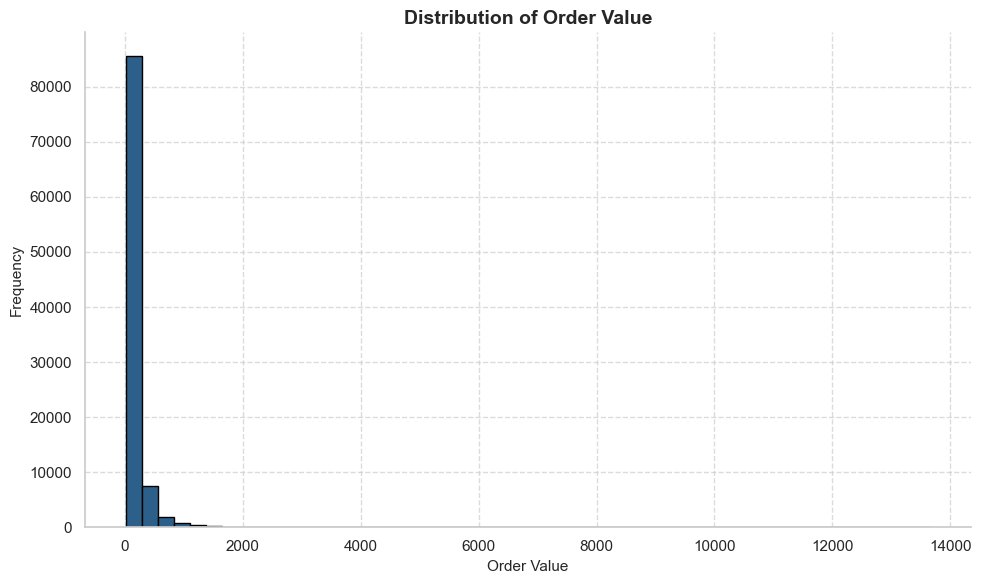

In [5]:
plt.figure(figsize=(10, 6))
df['total_order_value'].hist(bins=50, color=PRIMARY, edgecolor='black')
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
The distribution is highly right-skewed, indicating that a small number of high-value orders contribute disproportionately to total revenue.

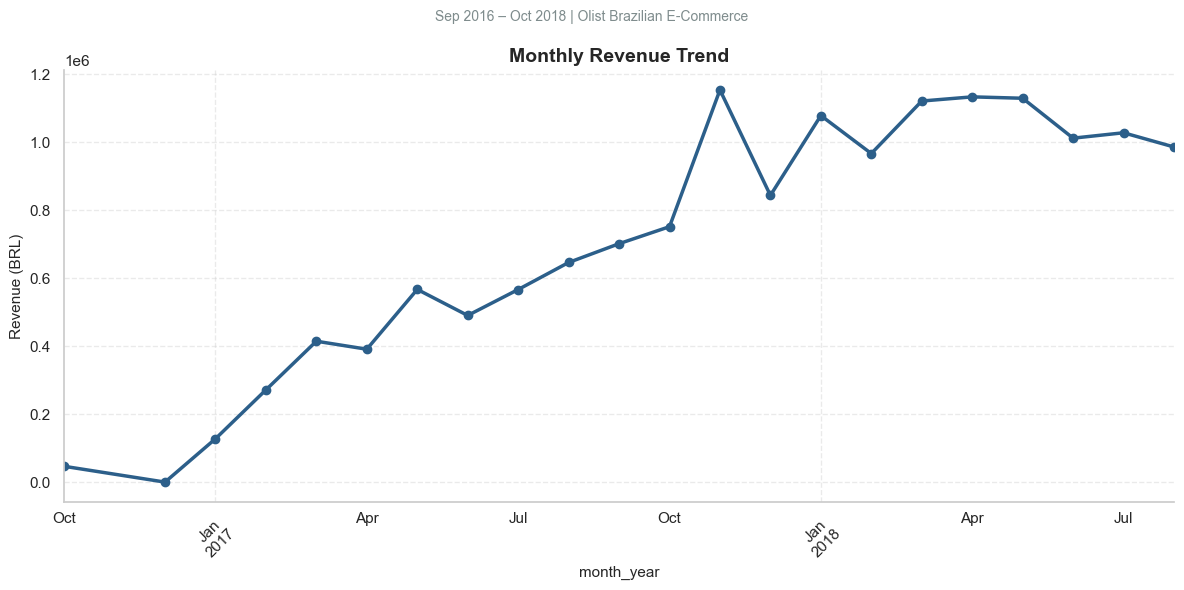

In [6]:
plt.figure(figsize=(12, 6))
monthly_revenue = df.groupby('month_year')['total_order_value'].sum()
monthly_revenue.plot(marker='o', color=PRIMARY, linewidth=2.5, markersize=6)
plt.title("Monthly Revenue Trend", fontweight='bold')
plt.suptitle("Sep 2016 – Oct 2018 | Olist Brazilian E-Commerce",
             fontsize=10, color=NEUTRAL, y=0.98)
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**  
Revenue shows a clear upward trend over time with occasional fluctuations, indicating business growth with seasonal variations.

## DELIVERY PERFORMANCE

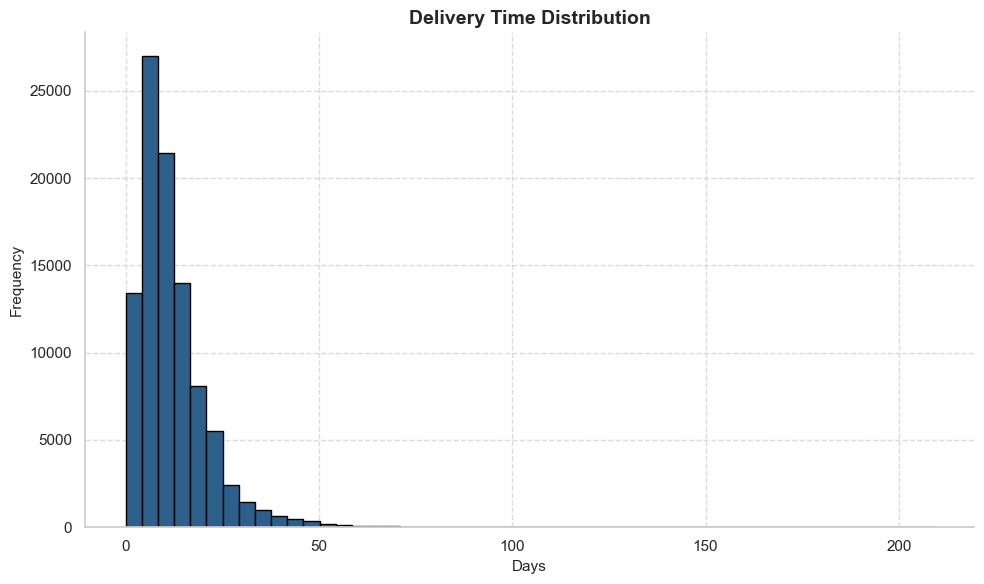

In [7]:
plt.figure(figsize=(10, 6))
df['delivery_time_days'].hist(bins=50, color=PRIMARY, edgecolor='black')
plt.title("Delivery Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
Most deliveries occur within a short time window, but there are some long-tail delays indicating inefficiencies in certain cases.

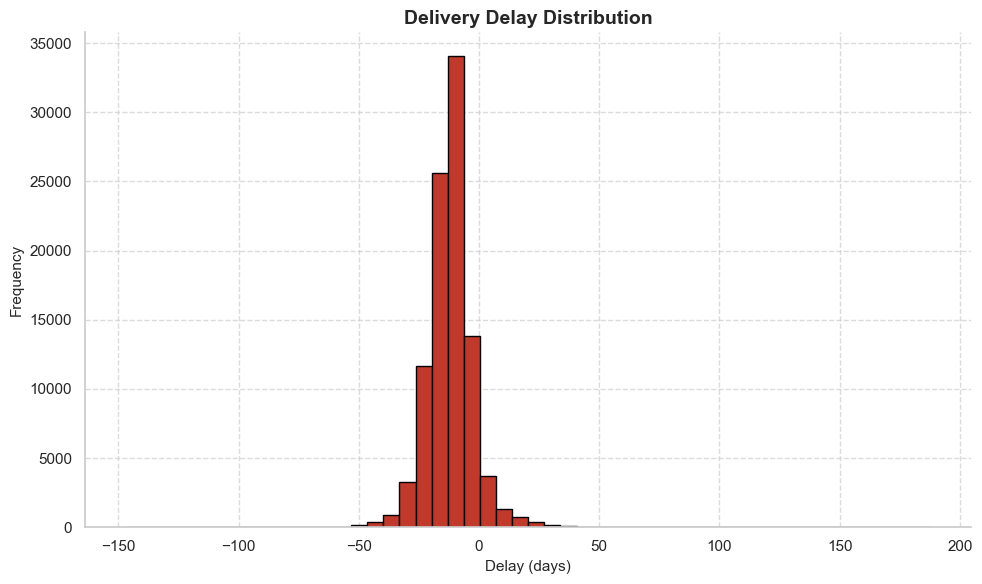

In [8]:
plt.figure(figsize=(10, 6))
df['delivery_delay_days'].hist(bins=50, color=NEGATIVE, edgecolor='black')
plt.title("Delivery Delay Distribution")
plt.xlabel("Delay (days)")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
df['delivery_status'] = df['delivery_delay_days'].apply(
    lambda x: 'Early' if x < 0 else ('On Time' if x == 0 else 'Late')
)

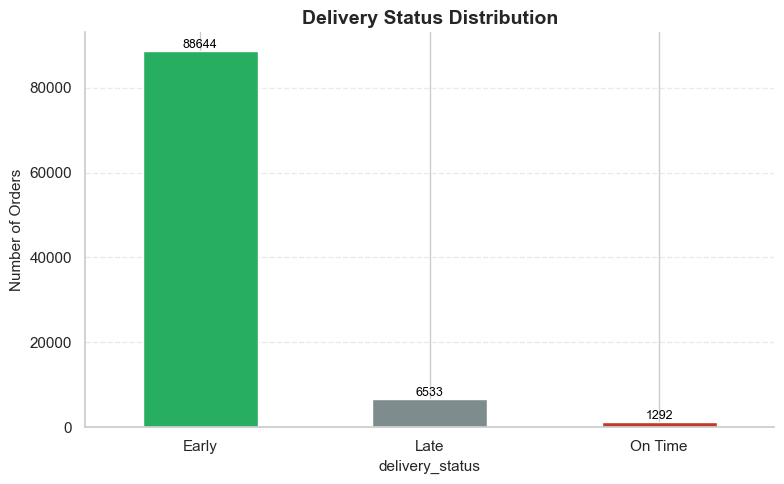

In [10]:
plt.figure(figsize=(8, 5))
ax = df['delivery_status'].value_counts().plot(
    kind='bar',
    color=[POSITIVE, NEUTRAL, NEGATIVE]
)
plt.title("Delivery Status Distribution")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.4)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

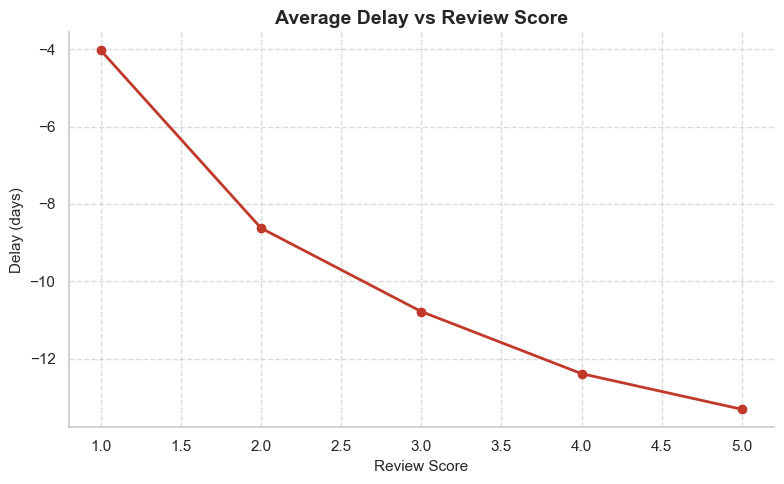

In [11]:
plt.figure(figsize=(8, 5))
df.groupby('review_score')['delivery_delay_days'].mean().plot(marker='o', color=NEGATIVE, linewidth=2)
plt.title("Average Delay vs Review Score")
plt.ylabel("Delay (days)")
plt.xlabel("Review Score")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
late_pct = (df['delivery_status'] == 'Late').mean() * 100
early_pct = (df['delivery_status'] == 'Early').mean() * 100
ontime_pct = (df['delivery_status'] == 'On Time').mean() * 100

print(f"Early deliveries  : {early_pct:.1f}%")
print(f"On-time deliveries: {ontime_pct:.1f}%")
print(f"Late deliveries   : {late_pct:.1f}%")

Early deliveries  : 91.9%
On-time deliveries: 1.3%
Late deliveries   : 6.8%


**Insight:**
6.8% of all deliveries are late overall. However state-level analysis reveals
AL (21.4%), MA (17.4%), and SE (15.2%) as critical problem regions — 3x the
national average — requiring targeted logistics intervention.

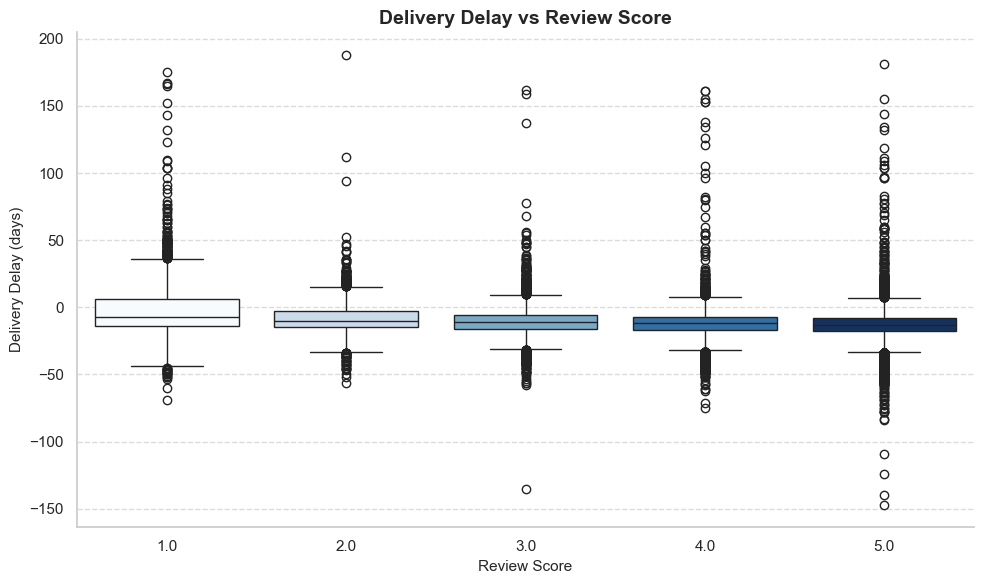

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='delivery_delay_days',
            data=df, hue='review_score', palette='Blues', legend=False)
plt.title("Delivery Delay vs Review Score")
plt.xlabel("Review Score")
plt.ylabel("Delivery Delay (days)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
Higher delivery delays are associated with lower review scores, confirming that delivery performance is a key driver of customer satisfaction.

## CUSTOMER ANALYSIS

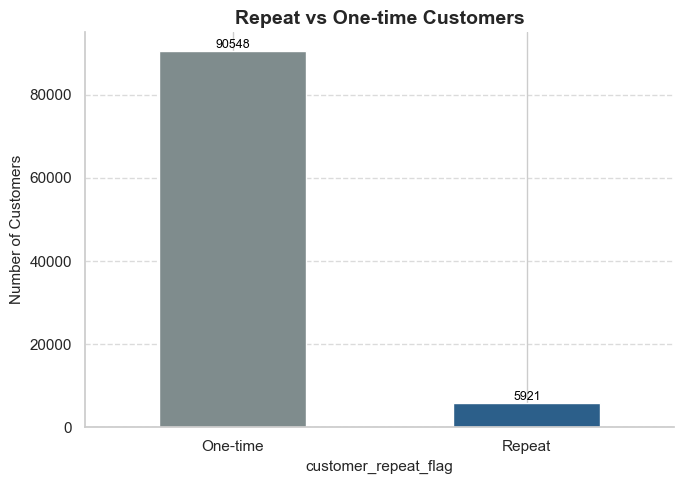

Repeat customer rate: 6.14%


In [14]:
plt.figure(figsize=(7, 5))
ax = df['customer_repeat_flag'].value_counts().plot(kind='bar', color=[NEUTRAL, PRIMARY])
plt.title("Repeat vs One-time Customers")
plt.ylabel("Number of Customers")
plt.xticks(ticks=[0, 1], labels=['One-time', 'Repeat'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

repeat_pct = df['customer_repeat_flag'].mean() * 100
print(f"Repeat customer rate: {repeat_pct:.2f}%")

**Insight:**  
The majority of customers are one-time buyers, indicating low retention and potential opportunity for loyalty strategies.

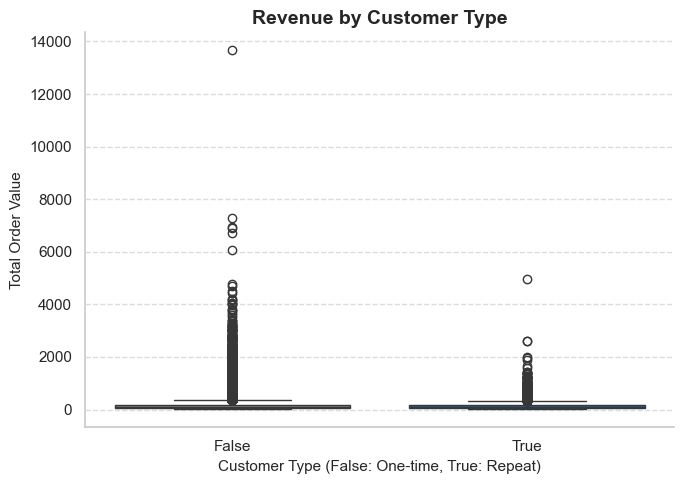

In [15]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='customer_repeat_flag', y='total_order_value',
            data=df, hue='customer_repeat_flag', palette=[NEUTRAL, PRIMARY], legend=False)
plt.title("Revenue by Customer Type")
plt.xlabel("Customer Type (False: One-time, True: Repeat)")
plt.ylabel("Total Order Value")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
Repeat customers tend to generate higher order values, suggesting they are more valuable to the business.

## PAYMENT ANALYSIS

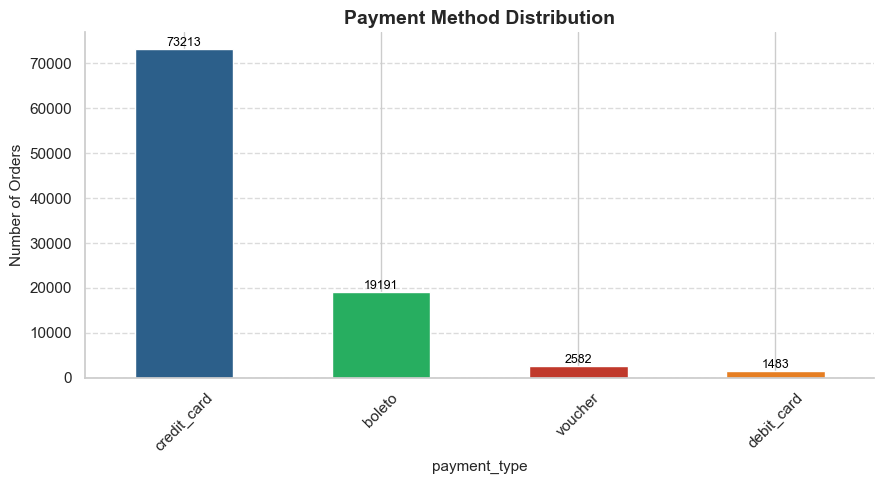

In [16]:
plt.figure(figsize=(9, 5))
ax = df['payment_type'].value_counts().plot(kind='bar', color=PALETTE_5)
plt.title("Payment Method Distribution")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

**Insight:**  
Credit card is the dominant payment method, indicating customer preference for flexible payment options.

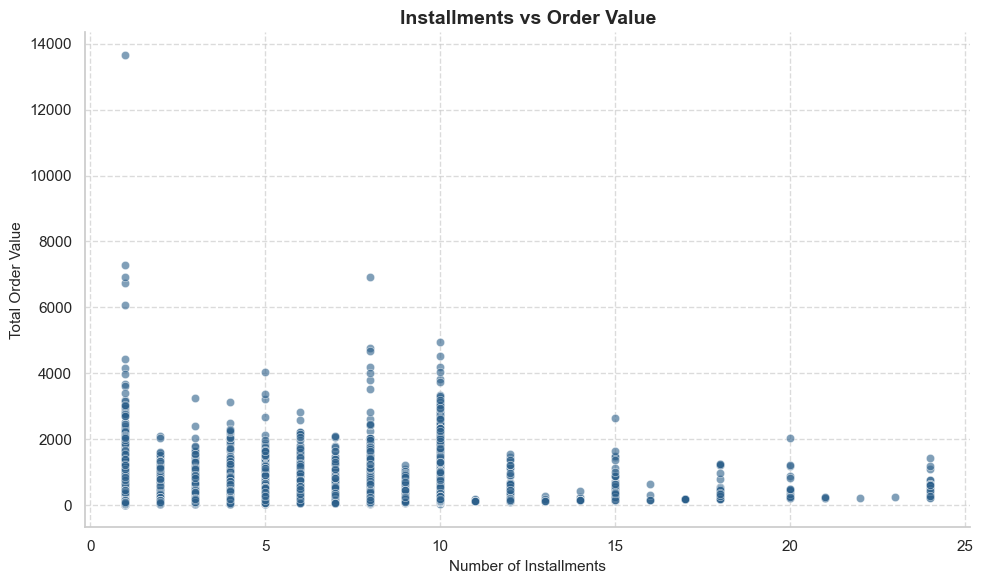

In [17]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='payment_installments', y='total_order_value', data=df, alpha=0.6, color=PRIMARY)
plt.title("Installments vs Order Value")
plt.xlabel("Number of Installments")
plt.ylabel("Total Order Value")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:**  
Higher-value orders are more likely to use installment-based payments, suggesting affordability influences purchasing behavior.

## REVIEW SCORE DISTRIBUTION

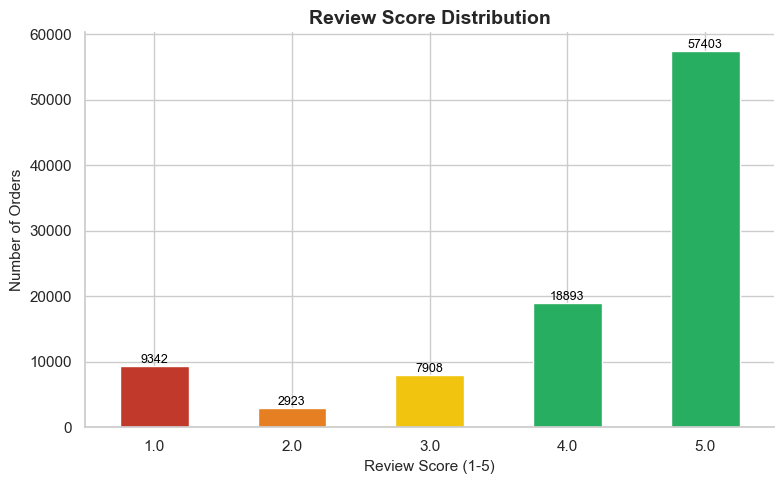

review_score
1.0     9342
2.0     2923
3.0     7908
4.0    18893
5.0    57403
Name: count, dtype: int64

Average review score: 4.16


In [18]:
plt.figure(figsize=(8,5))
score_colors = [NEGATIVE, HIGHLIGHT, "#F1C40F", POSITIVE, POSITIVE]
ax = df['review_score'].value_counts().sort_index().plot(
    kind='bar', color=score_colors
)
plt.title("Review Score Distribution")
plt.xlabel("Review Score (1-5)")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

print(df['review_score'].value_counts().sort_index())
avg_score = df['review_score'].mean()
print(f"\nAverage review score: {avg_score:.2f}")

## REVENUE CONCENTRATION

In [19]:
top_10_pct = df['total_order_value'].quantile(0.90)
high_value = df[df['total_order_value'] >= top_10_pct]

contribution = high_value['total_order_value'].sum() / df['total_order_value'].sum() * 100

print(f"Top 10% orders contribute: {contribution:.2f}% of total revenue")

Top 10% orders contribute: 38.05% of total revenue


## PRODUCT ANALYSIS

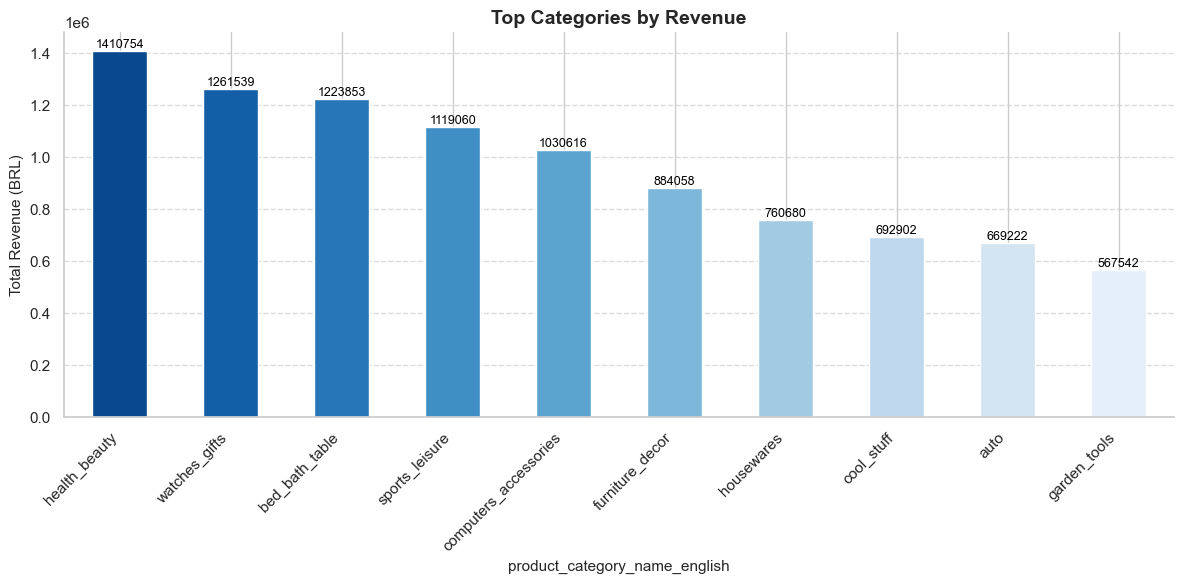

In [20]:
plt.figure(figsize=(12, 6))
top_categories = df.groupby('product_category_name_english')['total_order_value'].sum().sort_values(ascending=False).head(10)

ax = top_categories.plot(kind='bar', color=PALETTE_10)
plt.title("Top Categories by Revenue")
plt.ylabel("Total Revenue (BRL)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

## GEOGRAPHICAL ANALYSIS

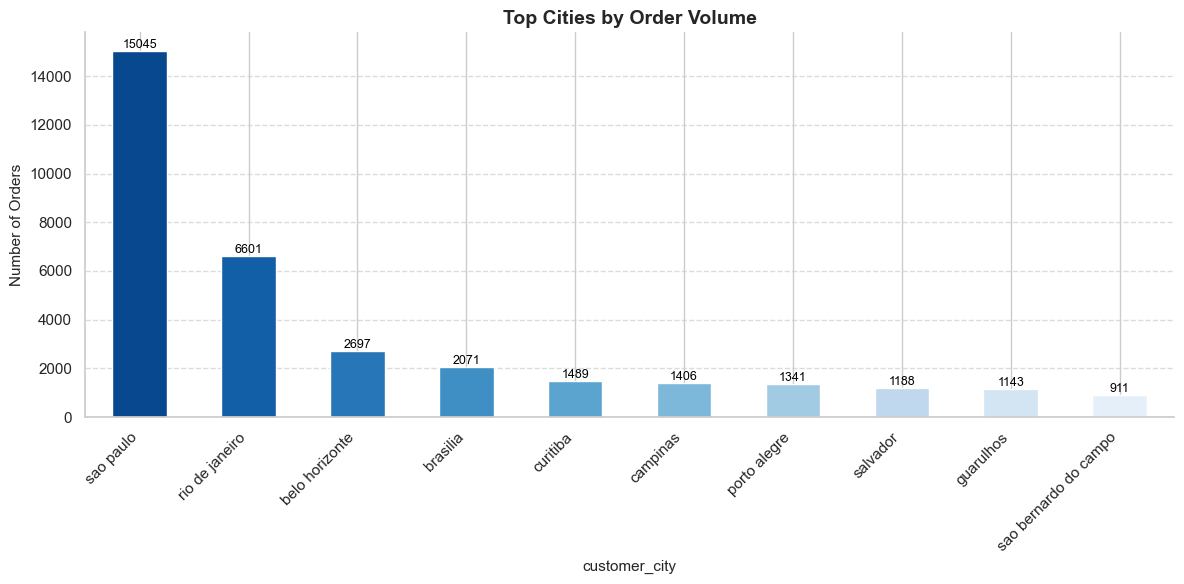

In [21]:
plt.figure(figsize=(12, 6))
top_cities = df['customer_city'].value_counts().head(10)

ax = top_cities.plot(kind='bar', color=PALETTE_10)
plt.title("Top Cities by Order Volume")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

## STATE-LEVEL REGIONAL ANALYSIS

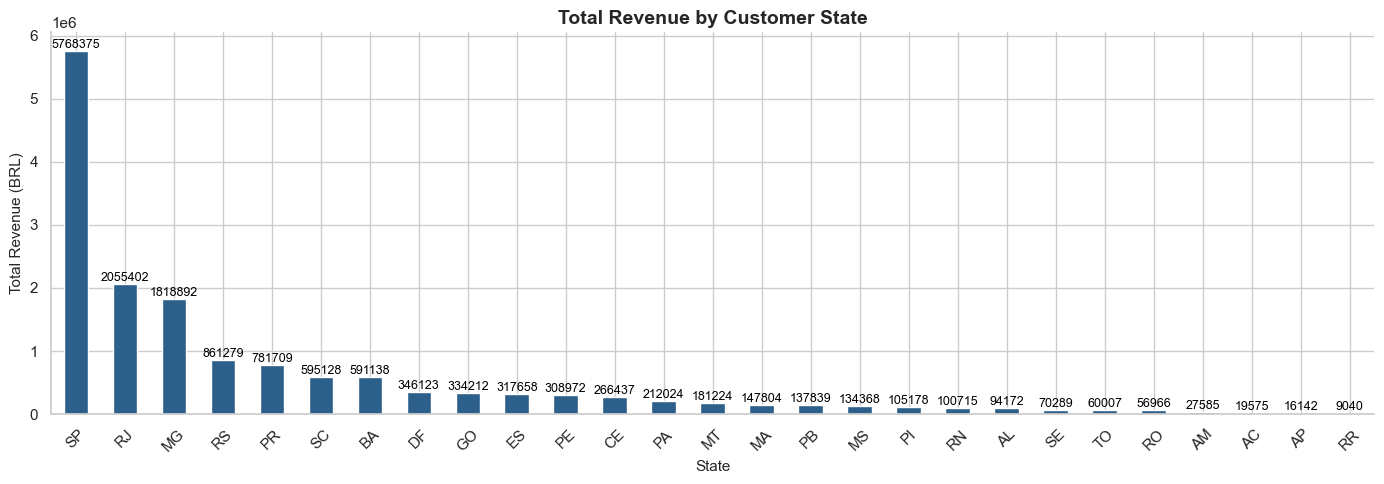

Top 5 states by revenue:
customer_state
SP    5768374.77
RJ    2055401.57
MG    1818891.67
RS     861278.79
PR     781708.80
Name: total_order_value, dtype: float64


In [22]:
state_revenue = df.groupby('customer_state')['total_order_value'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,5))
ax = state_revenue.plot(kind='bar', color=PRIMARY)
plt.title("Total Revenue by Customer State")
plt.xlabel("State")
plt.ylabel("Total Revenue (BRL)")
plt.xticks(rotation=45)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

print("Top 5 states by revenue:")
print(state_revenue.head())

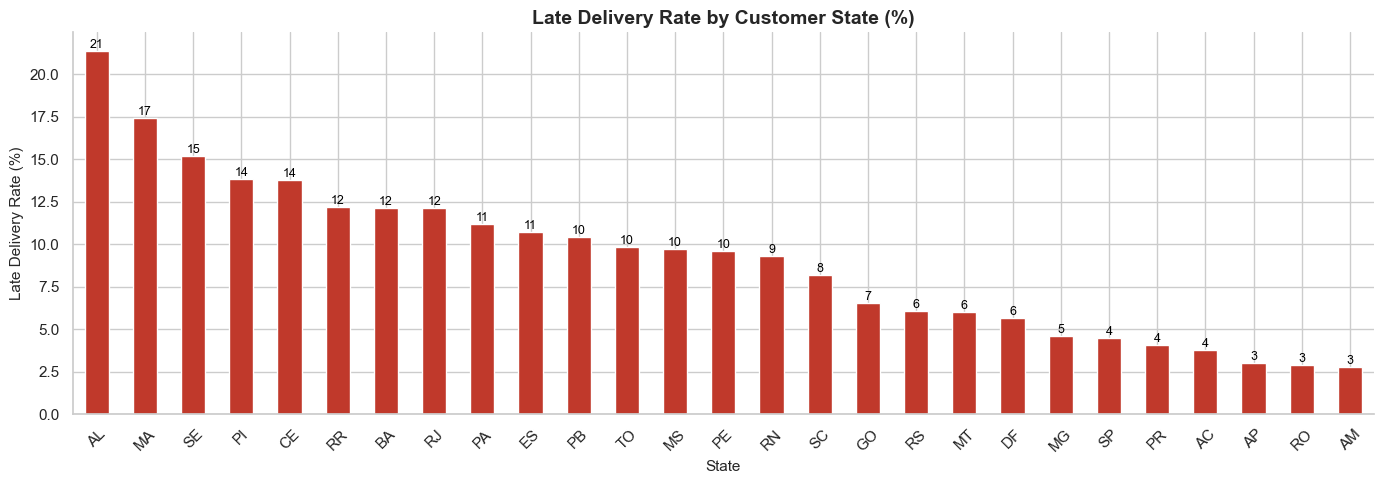

States with highest late delivery rate:
customer_state
AL    21.410579
MA    17.433752
SE    15.223881
PI    13.865546
CE    13.760751
Name: is_late_delivery, dtype: float64


In [23]:
late_by_state = df.groupby('customer_state')['is_late_delivery'].mean() * 100
late_by_state = late_by_state.sort_values(ascending=False)

plt.figure(figsize=(14,5))
ax = late_by_state.plot(kind='bar', color=NEGATIVE)
plt.title("Late Delivery Rate by Customer State (%)")
plt.xlabel("State")
plt.ylabel("Late Delivery Rate (%)")
plt.xticks(rotation=45)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

print("States with highest late delivery rate:")
print(late_by_state.head())

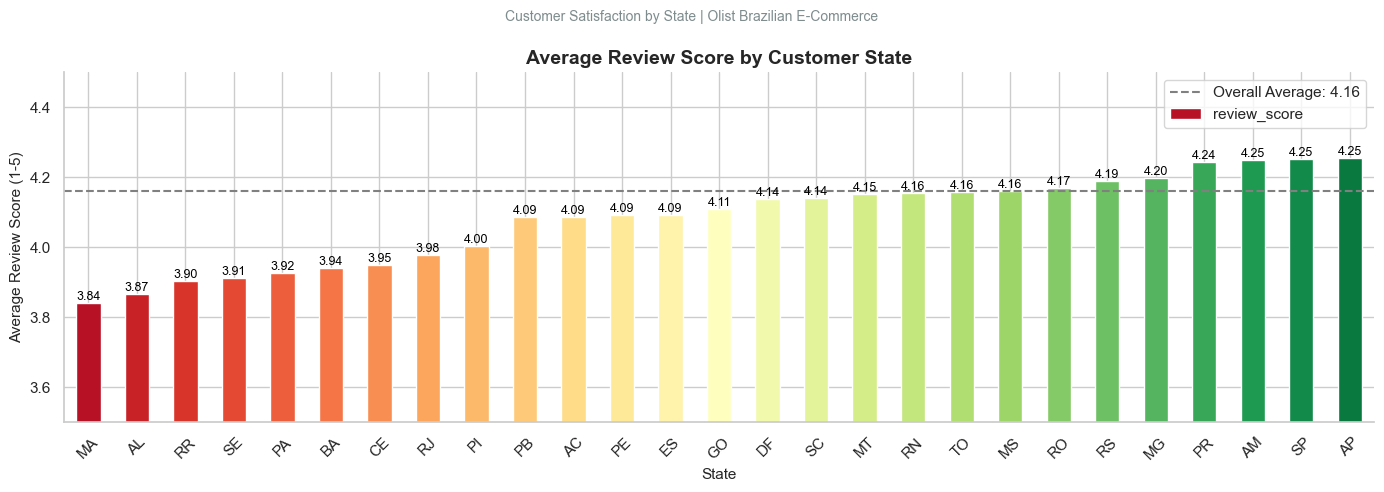

In [24]:
review_by_state = df.groupby('customer_state')['review_score'].mean().sort_values()

plt.figure(figsize=(14,5))
ax = review_by_state.plot(kind='bar', color=sns.color_palette("RdYlGn", n_colors=len(review_by_state)))
plt.title("Average Review Score by Customer State", fontweight='bold')
plt.suptitle("Customer Satisfaction by State | Olist Brazilian E-Commerce",
             fontsize=10, color=NEUTRAL, y=0.98)
plt.xlabel("State")
plt.ylabel("Average Review Score (1-5)")
plt.xticks(rotation=45)
add_bar_labels(ax, fmt='{:.2f}')
plt.axhline(y=avg_score, color='grey', linestyle='--', linewidth=1.5, label=f'Overall Average: {avg_score:.2f}')
plt.ylim(3.5, 4.5)
plt.legend()
plt.tight_layout()
plt.show()

## CORRELATION (OPTIONAL BUT STRONG)

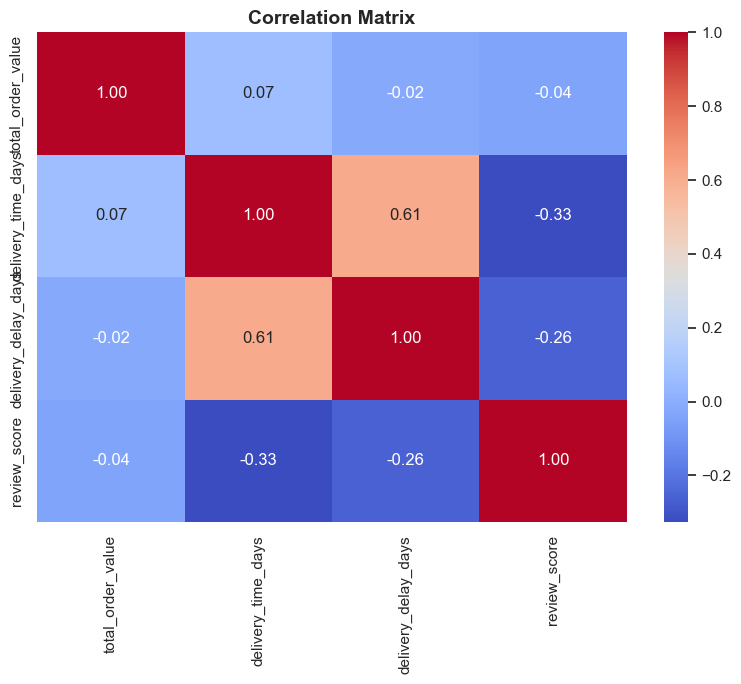

In [25]:
plt.figure(figsize=(8, 7))
corr_cols = [
    'total_order_value',
    'delivery_time_days',
    'delivery_delay_days',
    'review_score'
]

sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## FINAL INSIGHTS

# Key Insights — Decision Language

1. **Revenue is highly concentrated** — Top 10% of orders contribute 38% of
   total revenue. Upsell and retention efforts should prioritize this segment.

2. **6.8% of deliveries are late overall — but 21.4% in AL, 17.4% in MA, 15.2% in SE.**
   Logistics investment in these specific states has the highest impact potential.

3. **Retention rate is critically low at 6.14%** — 94 in 100 customers never
   return. A loyalty or re-engagement program targeting past buyers is the
   single highest-leverage retention action available.

4. **Average review score is 4.16/5** — 57,403 orders rated 5 stars. However,
   late deliveries consistently pull scores to 1–2, creating a fixable drag on
   overall satisfaction.

5. **SP, RJ, MG drive the majority of revenue** — São Paulo alone generates
   5.7M BRL. Underperforming states represent untapped growth with existing
   infrastructure.

# Conclusion

Three levers exist to grow revenue: fix delivery performance in high-delay
states (AL, MA, SE), convert the 93.86% of one-time buyers through loyalty
programs, and expand marketing in high-potential but underperforming states
beyond SP, RJ, and MG.